In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [2]:
with open('names.txt','r') as f:
    names= f.read().splitlines()

In [3]:
names

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [8]:
chars=sorted(set(''.join(names)))

In [11]:
stoi={ch:i+1 for i, ch in enumerate(chars)}
itos={i+1:ch for i, ch in enumerate(chars)}
stoi['.']=0
itos[0]='.'

In [13]:
# block size
block_size=3

X=[]
Y=[]
for word in names[:5]:
    context=[0] * block_size
    for ch in word + '.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '->', itos[ix])
        context=context[1:] + [ix]
X=torch.tensor(X)
Y=torch.tensor(Y)

... -> e
..e -> m
.em -> m
emm -> a
mma -> .
... -> o
..o -> l
.ol -> i
oli -> v
liv -> i
ivi -> a
via -> .
... -> a
..a -> v
.av -> a
ava -> .
... -> i
..i -> s
.is -> a
isa -> b
sab -> e
abe -> l
bel -> l
ell -> a
lla -> .
... -> s
..s -> o
.so -> p
sop -> h
oph -> i
phi -> a
hia -> .


In [14]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [16]:
C=torch.randn((len(chars)+1,2))   #vector of size 2 for each character

In [17]:
C[5]

tensor([0.5721, 0.3400])

In [ ]:
# vec5=F.one_hot(torch.tensor([5]), num_classes=len(chars)+1)

In [ ]:
# vec5.float() @ C   # same as C[5]
# f is 1*27 and C is 27*2, so the result is 1*2 with only C 5

tensor([[0.5721, 0.3400]])

In [23]:
C

tensor([[ 5.5449e-01,  4.3218e-01],
        [-5.7733e-01,  3.1938e-01],
        [-1.3619e+00, -1.3672e+00],
        [-4.8787e-01, -2.4774e-01],
        [ 6.0030e-01, -3.6969e-01],
        [ 5.7214e-01,  3.4002e-01],
        [-1.0151e+00,  1.4841e+00],
        [ 6.6185e-01,  1.2013e+00],
        [-9.7630e-01, -1.6848e-02],
        [-1.1277e+00,  7.5864e-01],
        [ 9.2260e-01, -3.6387e-01],
        [ 4.4120e-01, -5.9927e-01],
        [-9.8699e-01,  5.6509e-01],
        [ 1.3694e+00,  8.0099e-01],
        [-7.2489e-01,  1.9384e+00],
        [ 9.8594e-04, -6.2715e-02],
        [ 4.5703e-02,  9.4541e-02],
        [-3.0121e-01, -7.1659e-01],
        [-5.8576e-01,  1.1436e+00],
        [ 1.7416e-01, -2.8126e-01],
        [ 9.9129e-02,  3.9577e-02],
        [-1.0553e+00,  3.9758e-02],
        [ 1.8979e-01, -1.0630e-01],
        [-7.1868e-01,  1.8500e+00],
        [-4.9392e-01,  8.5389e-01],
        [ 3.3504e-01,  6.8199e-01],
        [-3.1853e-02,  7.2233e-01]])

In [24]:
C[[5,6]]

tensor([[ 0.5721,  0.3400],
        [-1.0151,  1.4841]])

In [30]:
C[torch.tensor([[1,2],[2,1]])]
# so in this way we can convert our X vector by replacing each index of character with itss vector

tensor([[[-0.5773,  0.3194],
         [-1.3619, -1.3672]],

        [[-1.3619, -1.3672],
         [-0.5773,  0.3194]]])

In [31]:
X[13,2]

tensor(1)

In [32]:
C[1]

tensor([-0.5773,  0.3194])

In [33]:
C[X[13,2]]

tensor([-0.5773,  0.3194])

In [38]:
emb = C[X]  # (N, block_size, d)
emb.shape

torch.Size([32, 3, 2])

In [36]:
W1=torch.randn((6,100))   # we have 3 characters and 2 is shape of each embedding
b1=torch.randn(100)

In [37]:
# we want to do embedding @ W1 + b1 
# but we need to reshape embedding to (N, block_size*d) and W1 to (d, 100)

In [41]:
emb[:,0,:].shape #  we want to  concatenate the embeddings of each character in the block so 0 1 and 2

torch.Size([32, 2])

In [43]:
x=torch.tensor([[1,2,3],[4,5,6]])
torch.unbind(x,dim=1)

(tensor([1, 4]), tensor([2, 5]), tensor([3, 6]))

In [47]:
torch.cat(torch.unbind(x,dim=0),dim=0)

tensor([1, 2, 3, 4, 5, 6])

In [48]:
len(torch.unbind(emb,dim=1))

3

In [50]:
torch.cat(torch.unbind(emb,dim=1),dim=1)  # (N, block_size*d)

tensor([[ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.5449e-01,
          4.3218e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.7214e-01,
          3.4002e-01],
        [ 5.5449e-01,  4.3218e-01,  5.7214e-01,  3.4002e-01,  1.3694e+00,
          8.0099e-01],
        [ 5.7214e-01,  3.4002e-01,  1.3694e+00,  8.0099e-01,  1.3694e+00,
          8.0099e-01],
        [ 1.3694e+00,  8.0099e-01,  1.3694e+00,  8.0099e-01, -5.7733e-01,
          3.1938e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.5449e-01,
          4.3218e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  9.8594e-04,
         -6.2715e-02],
        [ 5.5449e-01,  4.3218e-01,  9.8594e-04, -6.2715e-02, -9.8699e-01,
          5.6509e-01],
        [ 9.8594e-04, -6.2715e-02, -9.8699e-01,  5.6509e-01, -1.1277e+00,
          7.5864e-01],
        [-9.8699e-01,  5.6509e-01, -1.1277e+00,  7.5864e-01,  1.8979e-01,
         -1.0630e-01],
        [-1.1277e+00,  7.5864e

In [51]:
a=torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [ ]:
a.view(3,6)   # very fast

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17]])

In [54]:
a.storage()  # this is the underlying storage of the tensor
# on doing view we are not copying the data, just changing the view of the data

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [55]:
emb.shape

torch.Size([32, 3, 2])

In [ ]:
emb.view(32,6)   # this came to be same as torch.cat(torch.unbind(emb,dim=1),dim=1)

tensor([[ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.5449e-01,
          4.3218e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.7214e-01,
          3.4002e-01],
        [ 5.5449e-01,  4.3218e-01,  5.7214e-01,  3.4002e-01,  1.3694e+00,
          8.0099e-01],
        [ 5.7214e-01,  3.4002e-01,  1.3694e+00,  8.0099e-01,  1.3694e+00,
          8.0099e-01],
        [ 1.3694e+00,  8.0099e-01,  1.3694e+00,  8.0099e-01, -5.7733e-01,
          3.1938e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  5.5449e-01,
          4.3218e-01],
        [ 5.5449e-01,  4.3218e-01,  5.5449e-01,  4.3218e-01,  9.8594e-04,
         -6.2715e-02],
        [ 5.5449e-01,  4.3218e-01,  9.8594e-04, -6.2715e-02, -9.8699e-01,
          5.6509e-01],
        [ 9.8594e-04, -6.2715e-02, -9.8699e-01,  5.6509e-01, -1.1277e+00,
          7.5864e-01],
        [-9.8699e-01,  5.6509e-01, -1.1277e+00,  7.5864e-01,  1.8979e-01,
         -1.0630e-01],
        [-1.1277e+00,  7.5864e

In [60]:
h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d)

In [61]:
h.shape

torch.Size([32, 100])

In [62]:
W2=torch.randn((100,27))  # 100 is the hidden layer size and 27 is the output size
b2=torch.randn(27)


In [ ]:
logits= h@ W2 + b2  # (N,27)


In [ ]:
# probs=F.softmax(logits,dim=1)  # (N,27)
# loss=-probs[torch.arange(32), Y].log().mean()  # this gives the probabilities of the correct characters
loss=F.cross_entropy(logits, Y)  # this is the same as the above two lines

## Final

In [83]:
## dataset
def build_dataset(names,block_size=3):
    X=[]
    Y=[]
    for word in names:
        context=[0] * block_size
        for ch in word + '.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

X, Y = build_dataset(names, block_size)

In [84]:
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [88]:
g=torch.Generator().manual_seed(2147483647)  # for reproducibility
C=torch.randn((len(chars)+1, 2), generator=g)  # vector of size 100 for each character
W1=torch.randn((X.shape[1]*C.shape[1], 100), generator=g)   # vector of size 100 for each character
b1=torch.randn(100, generator=g)
W2=torch.randn((100, len(chars)+1), generator=g)  # 100 is the hidden layer size and 27 is the output size
b2=torch.randn(len(chars)+1, generator=g)
parameters=[C, W1, b1, W2, b2]


In [89]:
for p in parameters:
    p.requires_grad=True

In [97]:
lre=torch.linspace(-3, 0, 1000)  # learning rate exponential
lrs=10**lre  # learning rate

In [107]:
# backprop
losses=[]  # to store the losses
lres=[]  # to store the learning rates
lr=10**(-1)
for i in range(10000):
    # minibatch
    ix=torch.randint(0, X.shape[0], (32,), generator=g)  # random indices for minibatch
    X_batch=X[ix]  # (N, block_size)
    Y_batch=Y[ix]  # (N,)
    emb=C[X_batch]
    h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d
    logits= h@ W2 + b2  # (N,27
    loss=F.cross_entropy(logits, Y_batch)  # this is the same as the above two lines
    if(i%1000==0) :
        print(f"{i}----->{loss.item()}")
    # zero gradients
    for p in parameters:
        p.grad=None
    loss.backward()  #
    # compute gradients
    with torch.no_grad():
        for p in parameters:
            p -= p.grad * lr  # update the parameters with a learning rate of 0.1
    # lres.append(lre[i])  # append the learning rate to the list
    # losses.append(loss.item())  # append the loss to the list


0----->2.823983907699585
1000----->2.6318259239196777
2000----->2.5240097045898438
3000----->2.6316277980804443
4000----->2.3707287311553955
5000----->2.3564374446868896
6000----->2.4825308322906494
7000----->2.209474563598633
8000----->2.324676275253296
9000----->2.4827070236206055


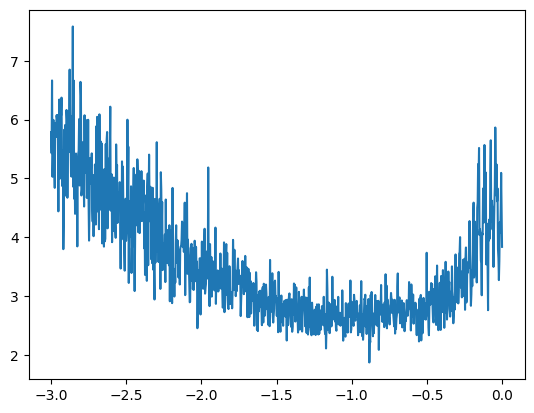

In [ ]:
# plt.plot(lres, losses)
# choose -1 as the best exponent for the learning rate we have minima there

In [108]:
emb=C[X]  # (N, block_size, d)
h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d)
logits= h@ W2 + b2  # (N,27)
loss=F.cross_entropy(logits, Y)  # this is the same as the above two lines
print(loss.item())

2.406430244445801


## splitting the dataset

In [171]:
# training split,validation split,test split
# 80,10,10
import random
random.seed(42)
random.shuffle(names)  # shuffle the names
n_train=int(len(names)*0.8)
n_val=int(len(names)*0.9)
X_train, Y_train = build_dataset(names[:n_train], block_size)
X_val, Y_val = build_dataset(names[n_train:n_val], block_size)
X_test, Y_test = build_dataset(names[n_val:], block_size)

In [199]:
C=torch.randn((len(chars)+1, 10), generator=g)  # vector of size 100 for each character
W1=torch.randn((X_train.shape[1]*C.shape[1], 300), generator=g)   # vector of size 100 for each character
b1=torch.randn(300, generator=g)
W2=torch.randn((300, len(chars)+1), generator=g)  # 100 is the hidden layer size and 27 is the output size
b2=torch.randn(len(chars)+1, generator=g)
parameters=[C, W1, b1, W2, b2]

In [200]:
for p in parameters:
    p.requires_grad=True


In [201]:
lre=torch.linspace(-3, 0, 1000)  # learning rate exponential
lrs=10**lre  # learning rate

In [202]:
C.shape, W1.shape, b1.shape, W2.shape, b2.shape

(torch.Size([27, 10]),
 torch.Size([30, 300]),
 torch.Size([300]),
 torch.Size([300, 27]),
 torch.Size([27]))

In [203]:
steps=[]
losses=[]  # to store the losses
lres=[]  # to store the learning rates
lr=10**(-2)
for i in range(200000):
    # minibatch
    ix=torch.randint(0, X_train.shape[0], (32,), generator=g)  # random indices for minibatch
    X_batch=X_train[ix]  # (N, block_size)
    Y_batch=Y_train[ix]  # (N,)
    emb=C[X_batch]
    h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d
    logits= h@ W2 + b2  # (N,27
    loss=F.cross_entropy(logits, Y_batch)  # this is the same as the above two lines
    if(i%1000==0) :
        print(f"{i}----->{loss.item()}")
    # zero gradients
    for p in parameters:
        p.grad=None
    loss.backward()  #
    # compute gradients
    if( i<1e5):
        lr=0.1
    else:
        lr=0.01
    with torch.no_grad():
        for p in parameters:
            p -= p.grad * lr  # update the parameters with a learning rate of 0.1
    steps.append(i)
    # lres.append(lre[i])  # append the learning rate to the list
    losses.append(loss.log10().item())  # append the loss to the list

0----->33.85932159423828
1000----->5.01660680770874
2000----->3.6513376235961914
3000----->3.550319194793701
4000----->3.116217613220215
5000----->2.6311206817626953
6000----->3.186525583267212
7000----->3.745429039001465
8000----->3.002354860305786
9000----->2.5062694549560547
10000----->2.7426416873931885
11000----->2.7967381477355957
12000----->2.7041711807250977
13000----->3.349581480026245
14000----->2.443315267562866
15000----->3.1905055046081543
16000----->2.611506462097168
17000----->2.7565934658050537
18000----->2.475454807281494
19000----->2.8320155143737793
20000----->2.5875635147094727
21000----->2.1516804695129395
22000----->2.9591615200042725
23000----->2.6959609985351562
24000----->3.1219301223754883
25000----->2.1769142150878906
26000----->2.0982449054718018
27000----->2.486462116241455
28000----->3.8179972171783447
29000----->2.4668257236480713
30000----->3.195495843887329
31000----->2.558483600616455
32000----->2.941598653793335
33000----->2.7581300735473633
34000----

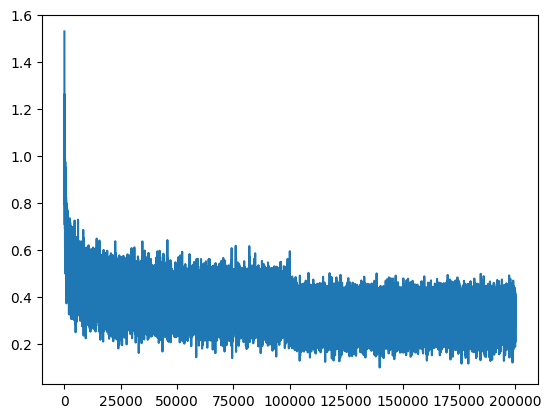

In [204]:
plt.plot(steps, losses)

In [205]:
# plt.figure(figsize=(8, 8))
# plt.scatter(C[:, 0].data, C[:, 1].data, s=100) 
# for i in range(C.shape[0]):
#     plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], fontsize=12, ha='center', va='center')
# plt.grid('minor')

In [206]:
emb=C[X_val]
h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d)
logits= h@ W2 + b2  # (N,27)
loss=F.cross_entropy(logits, Y_val)  # this is the same as the above two lines
loss

tensor(2.1500, grad_fn=<NllLossBackward0>)

## inference

In [208]:
generator = torch.Generator().manual_seed(2147483647)  # for reproducibility

for _ in range(20):
    context=[0]*block_size
    out=''
    while True:
        emb=C[torch.tensor([context])]
        h=torch.tanh(emb.view(emb.shape[0],block_size*emb.shape[2])@ W1+b1)  # (N, block_size*d)
        logits= h@ W2 + b2  # (N,27)
        probs=F.softmax(logits, dim=1)
        print(probs)
        ix=torch.multinomial(probs, num_samples=1, generator=generator).item()  # sample from the distribution
        if ix==0:  # if we reach the end of the word
            break
        out+=itos[ix]  # append the character to the output
        context=context[1:] + [ix]  # update the context
    print(out)  # print the generated word

tensor([[3.4011e-05, 1.4590e-01, 4.0857e-02, 4.8360e-02, 3.8214e-02, 5.5572e-02,
         1.3166e-02, 1.9997e-02, 2.4692e-02, 1.8713e-02, 9.3672e-02, 6.8352e-02,
         4.4404e-02, 7.1141e-02, 4.3821e-02, 1.7424e-02, 1.9689e-02, 3.5841e-03,
         5.0128e-02, 6.1906e-02, 4.1135e-02, 3.5815e-03, 9.7363e-03, 7.9180e-03,
         4.6245e-03, 1.6836e-02, 3.6543e-02]], grad_fn=<SoftmaxBackward0>)
tensor([[1.0072e-05, 4.2227e-01, 2.0369e-05, 4.2404e-03, 9.3636e-06, 5.5298e-02,
         1.2369e-05, 8.8111e-06, 2.4924e-01, 3.9183e-02, 1.5023e-03, 1.0718e-03,
         2.9618e-02, 4.9222e-04, 1.4985e-03, 1.4316e-01, 1.5167e-04, 1.2956e-06,
         2.7149e-02, 3.3374e-04, 5.3979e-04, 6.9348e-03, 1.1830e-04, 2.0620e-03,
         1.7627e-07, 1.5071e-02, 9.4431e-06]], grad_fn=<SoftmaxBackward0>)
tensor([[2.7498e-03, 9.8088e-02, 8.1381e-04, 6.5305e-02, 2.8082e-02, 5.7046e-02,
         3.0589e-04, 1.3252e-03, 6.5264e-03, 3.6185e-02, 4.1568e-03, 2.7876e-04,
         1.4980e-01, 6.8460e-02, 1.8299e